### DADVI linear regression example

This is a really simple example of deterministic ADVI (DADVI) in action.

It's based on the notebook [here](https://www.pymc.io/projects/docs/en/stable/learn/core_notebooks/GLM_linear.html).

We'll fit the model with both NUTS and DADVI and compare the result.

Of course, this isn't the greatest use case for DADVI, since the fit with NUTS is super-fast anyway, so there's no reason to do variational inference. But we can check it to make sure they give similar results on a simple model.

In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm

from pymc import HalfCauchy, Model, Normal, sample

print(f"Running on PyMC v{pm.__version__}")

Running on PyMC v6.0.1


In [2]:
RANDOM_SEED = 8927
rng = np.random.default_rng(RANDOM_SEED)

%config InlineBackend.figure_format = 'retina'

In [3]:
size = 200
true_intercept = 1
true_slope = 2

x = np.linspace(0, 1, size)
# y = a + b*x
true_regression_line = true_intercept + true_slope * x
# add noise
y = true_regression_line + rng.normal(scale=0.5, size=size)

data = pd.DataFrame({"x": x, "y": y})

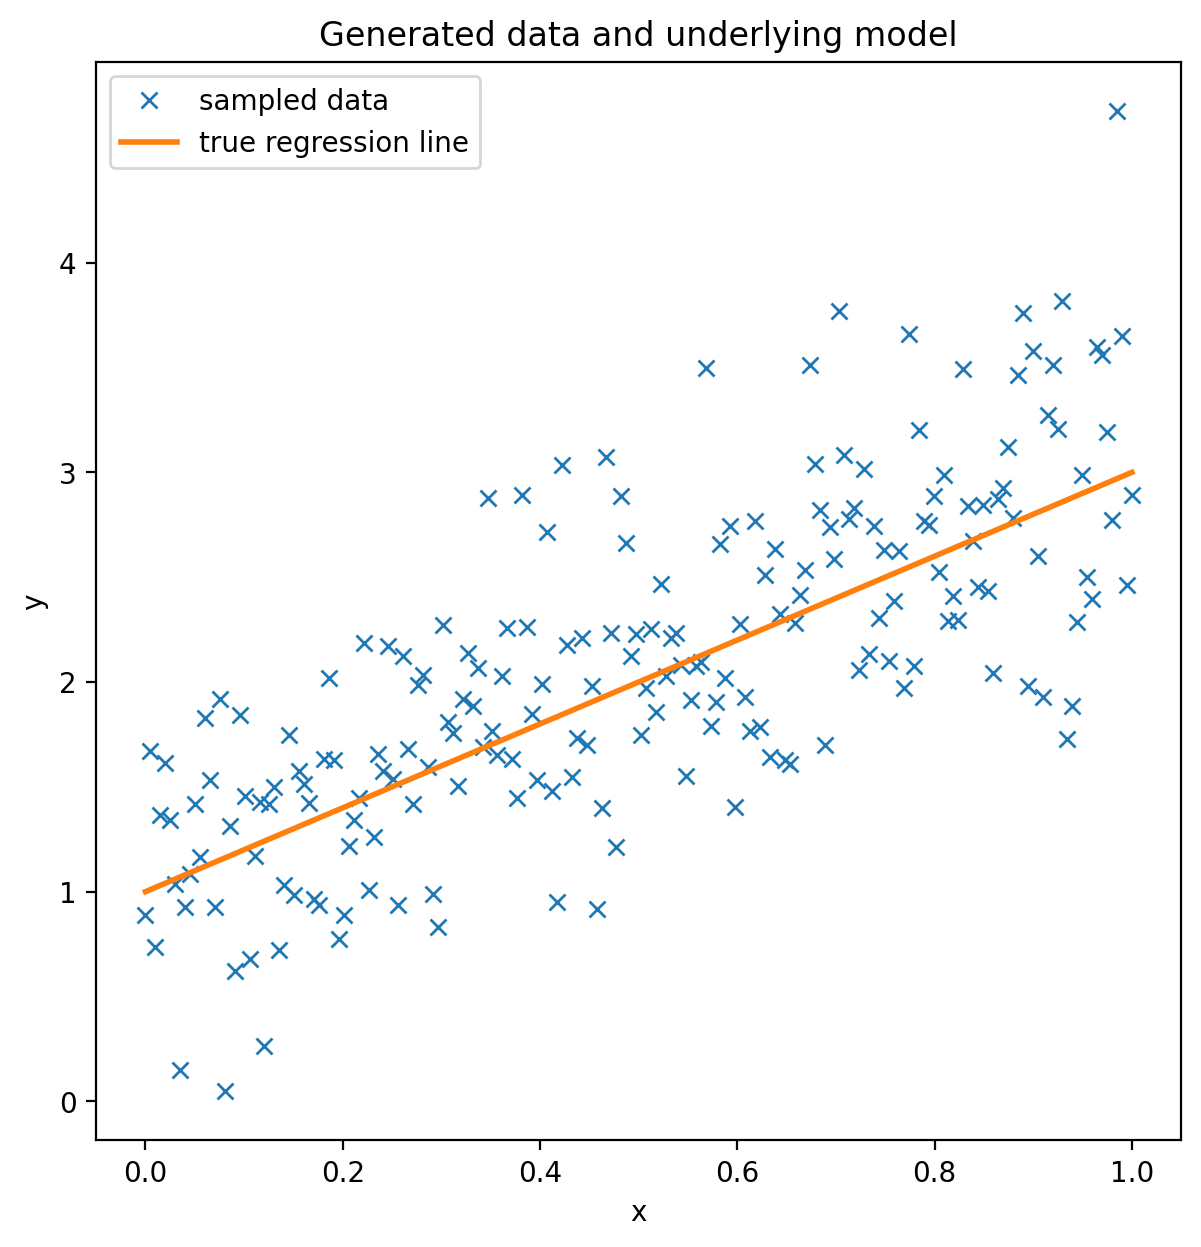

In [4]:
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, xlabel="x", ylabel="y", title="Generated data and underlying model")
ax.plot(x, y, "x", label="sampled data")
ax.plot(x, true_regression_line, label="true regression line", lw=2.0)
plt.legend(loc=0)

In [5]:
with Model() as model:  # model specifications in PyMC are wrapped in a with-statement
    # Define priors
    sigma = HalfCauchy("sigma", beta=10)
    intercept = Normal("Intercept", 0, sigma=20)
    slope = Normal("slope", 0, sigma=20)

    # Define likelihood
    likelihood = Normal("y", mu=intercept + slope * x, sigma=sigma, observed=y)

    # Inference!
    # draw 3000 posterior samples using NUTS sampling
    idata = sample(3000, random_seed=rng)

NUTS[nutpie]: [sigma, Intercept, slope]


Output()

We've done inference with NUTS. Now we can try DADVI.

In [6]:
# This single import should be all that's needed
from pymc_extras.inference import fit_dadvi

In [7]:
# We can fit DADVI now. It prints some progress of its convergence -- note we could change this
# to look different / remove it.
# Note that unlike regular ADVI, deterministic ADVI converges automatically. This is one of its key advantages.
with model:
    dadvi_res = fit_dadvi(random_seed=RANDOM_SEED)

Output()

In [8]:
# DADVI returns draws like MCMC
dadvi_res

<xarray.DataTree>
Group: /
├── Group: /posterior
│       Dimensions:    (chain: 1, draw: 1000)
│       Coordinates:
│         * chain      (chain) int64 8B 0
│         * draw       (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
│       Data variables:
│           sigma      (chain, draw) float64 8kB 0.4887 0.5071 0.5663 ... 0.5015 0.5033
│           Intercept  (chain, draw) float64 8kB 1.054 1.009 1.043 ... 1.041 1.038 1.045
│           slope      (chain, draw) float64 8kB 2.025 1.984 2.2 ... 1.963 2.008 2.143
│       Attributes:
│           created_at:                 2026-06-19T02:43:46.817151+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.0.1
│           sample_dims:                ['chain', 'draw']
├── Group: /optimizer_result
│       Dimensions:    (variables: 6)
│       Coordinates:
│         * variables  (variables) <U11 264B 'sigma_log__' 'Intercept' ... 'slope'
│       Data variables:
│           x          (variables) float64 48B -0.6514 1.037 2.05 -3.034 -3.428 -2.516
│           fun        float64 8B 174.1
│           success    bool 1B False
│           message    <U58 232B 'A bad approximation caused failure to predict impro...
│           jac        (variables) float64 48B 1.627e-10 -2.203e-10 ... 3.865e-08
│           nit        int64 8B 20
│           nfev       int64 8B 22
│           njev       int64 8B 19
│           status     int64 8B 2
│           nhev       int64 8B 81
│           method     <U9 36B 'trust-ncg'
├── Group: /observed_data
│       Dimensions:  (y_dim_0: 200)
│       Coordinates:
│         * y_dim_0  (y_dim_0) int64 2kB 0 1 2 3 4 5 6 7 ... 193 194 195 196 197 198 199
│       Data variables:
│           y        (y_dim_0) float64 2kB 0.8887 1.673 0.7346 ... 3.651 2.462 2.891
│       Attributes:
│           created_at:                 2026-06-19T02:43:46.825575+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.0.1
│           sample_dims:                []
└── Group: /constant_data
        Attributes:
            created_at:                 2026-06-19T02:43:46.826242+00:00
            creation_library:           ArviZ
            creation_library_version:   1.1.0
            creation_library_language:  Python
            inference_library:          pymc
            inference_library_version:  6.0.1
            sample_dims:                []

/Users/jessegrabowski/mambaforge/envs/pymc-extras/lib/python3.14/site-packages/arviz_plots/plot_collection.py:56: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'chain' ('chain',) The recommendation is to set join explicitly for this case.
  data = xr.concat(ds_list, dim="model").assign_coords(model=list(data))
/Users/jessegrabowski/mambaforge/envs/pymc-extras/lib/python3.14/site-packages/arviz_plots/plot_collection.py:56: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'draw' ('draw',) The recommendation is to set 

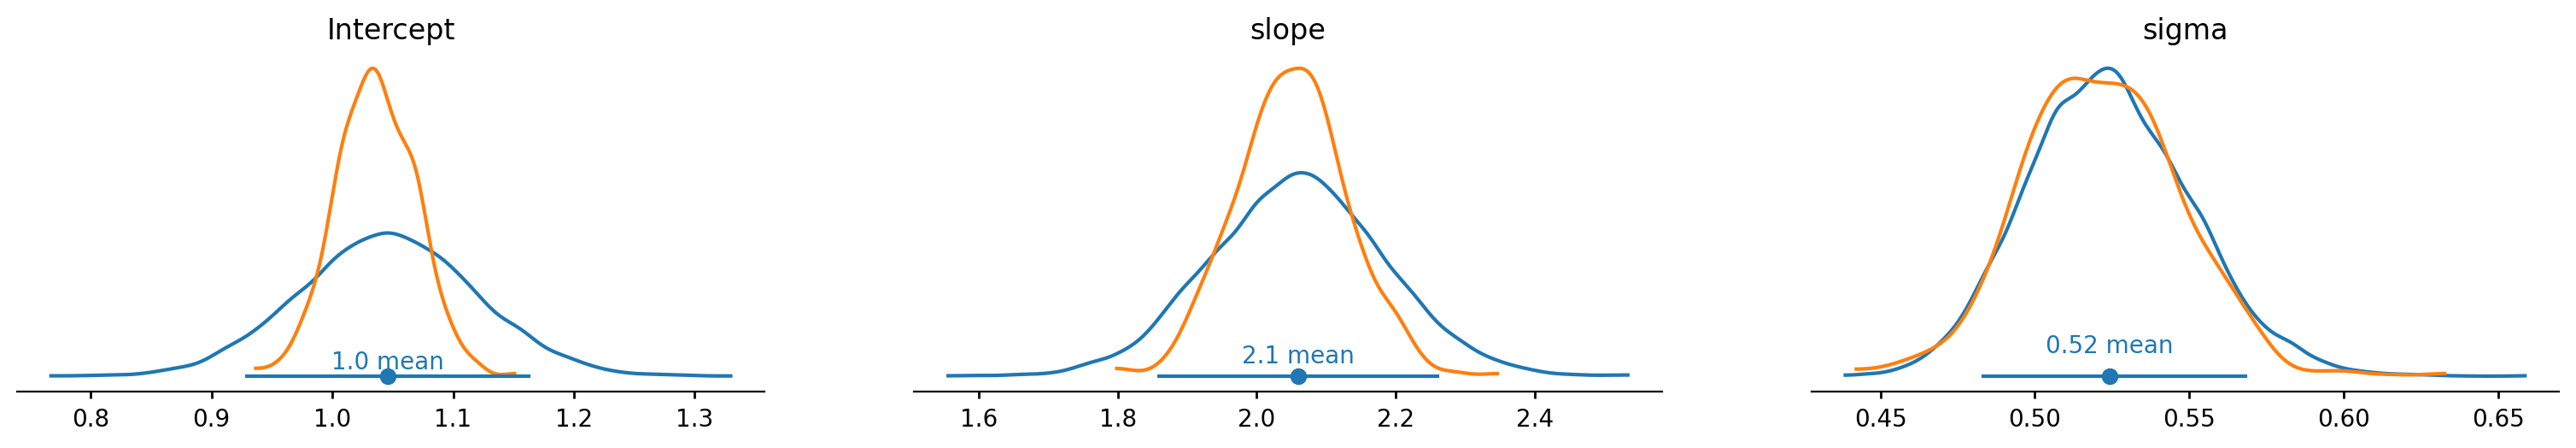

In [9]:
var_names = ["Intercept", "slope", "sigma"]
az.plot_dist({"MCMC": idata, "DADVI": dadvi_res}, var_names=var_names)

We can see that the posteriors don't align perfectly. DADVI does a pretty good job matching the means, but underestimates the variance somewhat. However, often DADVI is much faster than MCMC, and so this is a tradeoff that can make sense.

Note that DADVI as explained in the [paper](https://jmlr.org/papers/volume25/23-1015/23-1015.pdf) has further tools to make variances more accurate, which we plan to add to PyMC later on. For now, its key advantage is that it converges automatically and reliably, removing one headache from ADVI.